## Title
Analisi de datos (EDA)
### By:
Dovaribi Carupia Yagari

### Date:
2026-08-20

### Description:

Realizar un buen análisis de datos exploratorio (EDA) para caracterizar los datos disponibles para el proyecto. Crear una nueva rama de git (Usar [Gitflow](https://joserzapata.github.io/courses/ciencia-datos-en-produccion/control-versiones/branching-model/)).

> Tomar como ejemplo los pasos de: <https://joserzapata.github.io/post/ciencia-datos-proyecto-python/3-analysis/>

Si su proyecto tiene muchos datos puede dividir el análisis en 3 notebooks diferentes:
- Análisis univariable
- Análisis bivariable
- Análisis multivariable

En este proceso, se incluye :

- Compresión detallada de las características y el esquema de datos.
- Identificación de la preparación de datos y la ingeniería de atributos que se necesitan si se fuera a implementar un modelo de machine learning

- Estudiar cada atributo y sus características (Análisis Univariable):
    - Nombre
    - Tipo de dato (categórico ordinal, nominal, numérico int / float, acotado / no acotado, texto, estructurado, fechas, etc.)
    - porcentaje (%) de valores nulos.
    - valores exactamente duplicados (filas y columnas)
    - Ruido y tipo de ruido (estocástico, valores atípicos, errores de redondeo, etc.)
    - ¿Son posiblemente útiles para el proyecto?
    - Descripción estadística (dependiendo del tipo de dato): por ejemplo para los numéricos
        - Tendencia Central (media, mediana, moda, max, min, etc)
        - Medidas de dispersión (Rango, IQR, cuartiles, varianza, desviación estándar, skewness y kurtosis)
        - Tipo de distribución (gaussiana, uniforme, logarítmica, etc.)
    - Analice los datos para crear las reglas de validación de los datos que serán usadas en otra etapa del proyecto.
- Para los proyectos de aprendizaje supervisado, identifique los atributos objetivo (target).
- Visualización de los datos.
- Estudiar las relaciones entre atributos (Análisis Bivariable)
- Estudiar las relaciones entre varios atributos (Análisis Multivariable)
- Estudiar cómo resolver el problema manualmente. (modelo simple Viable o heurísticas)
- Identificar las transformaciones que tal vez se puedan aplicar.
- Identificar datos adicionales que pueden ser útiles.

> Puede utilizar las librerías o herramientas que considere para resolver la tarea y contestar las preguntas.
> Utilice sistemas automáticos como [Data science Agent](https://developers.googleblog.com/en/data-science-agent-in-colab-with-gemini/) pueden ver un tutorial en este [Link](https://www.youtube.com/watch?v=1WAjTyYEIos)

# Entregables

Notebook con los resultados del análisis exploratorio de los datos, conclusiones e información de los datos
¿Sugerir si se puede realizar un modelo Heurístico que sea viable?

Se debe realizar un Pull request para ingresar el notebook a la rama`main` para esto debe tener mínimo 1 revisiones de otras personas del Curso y que pase los check del CI/CD.



## 📚 Import  libraries

In [2]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## 💾 Load data

In [3]:
# Configuración visual y de logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
sns.set_theme(style="whitegrid")

# Rutas de lectura (apuntando a nuestro archivo limpio del Issue 2)
DATA_DIR = Path("../..") / "data" / "02_intermediate"
FILE_PATH = DATA_DIR / "pacientes_higado_exploracion.parquet"

# Carga de datos
logging.info("Cargando dataset desde: %s", FILE_PATH)
df = pd.read_parquet(FILE_PATH)

# Aseguramos los tipos definidos en la etapa de exploración
df["Age"] = df["Age"].astype("Int64")
df["Gender"] = df["Gender"].astype("category")
df["Diagnosis"] = df["Diagnosis"].astype("Int64").astype("category")

print(f"Dimensiones del dataset: {df.shape[0]} filas, {df.shape[1]} columnas")
display(df.head())

2026-08-20 23:00:28,644 - INFO - Cargando dataset desde: ..\..\data\02_intermediate\pacientes_higado_exploracion.parquet


Dimensiones del dataset: 663 filas, 11 columnas


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Diagnosis
0,65.0,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1.0
1,62.0,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1.0
2,62.0,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1.0
3,58.0,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1.0
4,72.0,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1.0


## Analisis de calida inicial

In [4]:
# 2. Análisis de Calidad General
print("=" * 50)
print("1. VALORES EXACTAMENTE DUPLICADOS (FILAS)")
print("=" * 50)
duplicados = df.duplicated().sum()
print(f"Cantidad de filas exactamente duplicadas: {duplicados}")
if duplicados > 0:
    print(f"Porcentaje de duplicados: {(duplicados / len(df)) * 100:.2f}%\n")
    display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head())

print("\n" + "=" * 50)
print("2. PORCENTAJE DE VALORES NULOS POR ATRIBUTO")
print("=" * 50)
nulos_porcentaje = (df.isna().sum() / len(df)) * 100
nulos_df = pd.DataFrame({"Porcentaje_Nulos (%)": nulos_porcentaje})
nulos_df = nulos_df[nulos_df["Porcentaje_Nulos (%)"] > 0].sort_values(
    by="Porcentaje_Nulos (%)", ascending=False
)
display(nulos_df)

1. VALORES EXACTAMENTE DUPLICADOS (FILAS)
Cantidad de filas exactamente duplicadas: 60
Porcentaje de duplicados: 9.05%



,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Diagnosis
570,16.0,Male,2.6,1.2,236.0,131.0,90.0,5.4,2.6,0.90,1.0
648,16.0,Male,2.6,1.2,236.0,131.0,90.0,5.4,2.6,0.90,1.0
569,16.0,Male,7.7,4.1,268.0,213.0,168.0,7.1,4.0,1.20,1.0
647,16.0,Male,7.7,4.1,268.0,213.0,168.0,7.1,4.0,1.20,1.0
102,17.0,Male,0.9,0.2,224.0,36.0,45.0,6.9,4.2,1.55,1.0



2. PORCENTAJE DE VALORES NULOS POR ATRIBUTO


,Porcentaje_Nulos (%)
Alamine_Aminotransferase,2.865762
Alkaline_Phosphotase,2.564103
Diagnosis,2.262443
Aspartate_Aminotransferase,1.809955
Gender,1.206637
Direct_Bilirubin,1.055807
Total_Protiens,1.055807
Total_Bilirubin,0.904977
Albumin_and_Globulin_Ratio,0.603318
Albumin,0.301659


ANÁLISIS UNIVARIABLE - DESCRIPCIÓN ESTADÍSTICA


,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Diagnosis
count,662.000000,657.000000,656.000000,646.000000,644.000000,651.000000,656.000000,661.000000,659.000000,648.000000
mean,44.823263,3.384018,1.528659,285.312693,80.790373,110.964670,6.465244,3.118759,0.941851,1.290123
std,16.177173,6.278501,2.877276,233.440140,185.487725,278.323459,1.069214,0.786118,0.322153,0.454170
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.000000,23.000000,26.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,43.000000,6.500000,3.100000,0.930000,1.000000
75%,57.000000,2.700000,1.300000,291.500000,60.000000,90.000000,7.200000,3.700000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


2026-08-20 23:00:35,222 - INFO - Generando gráficos de distribución y diagramas de caja...


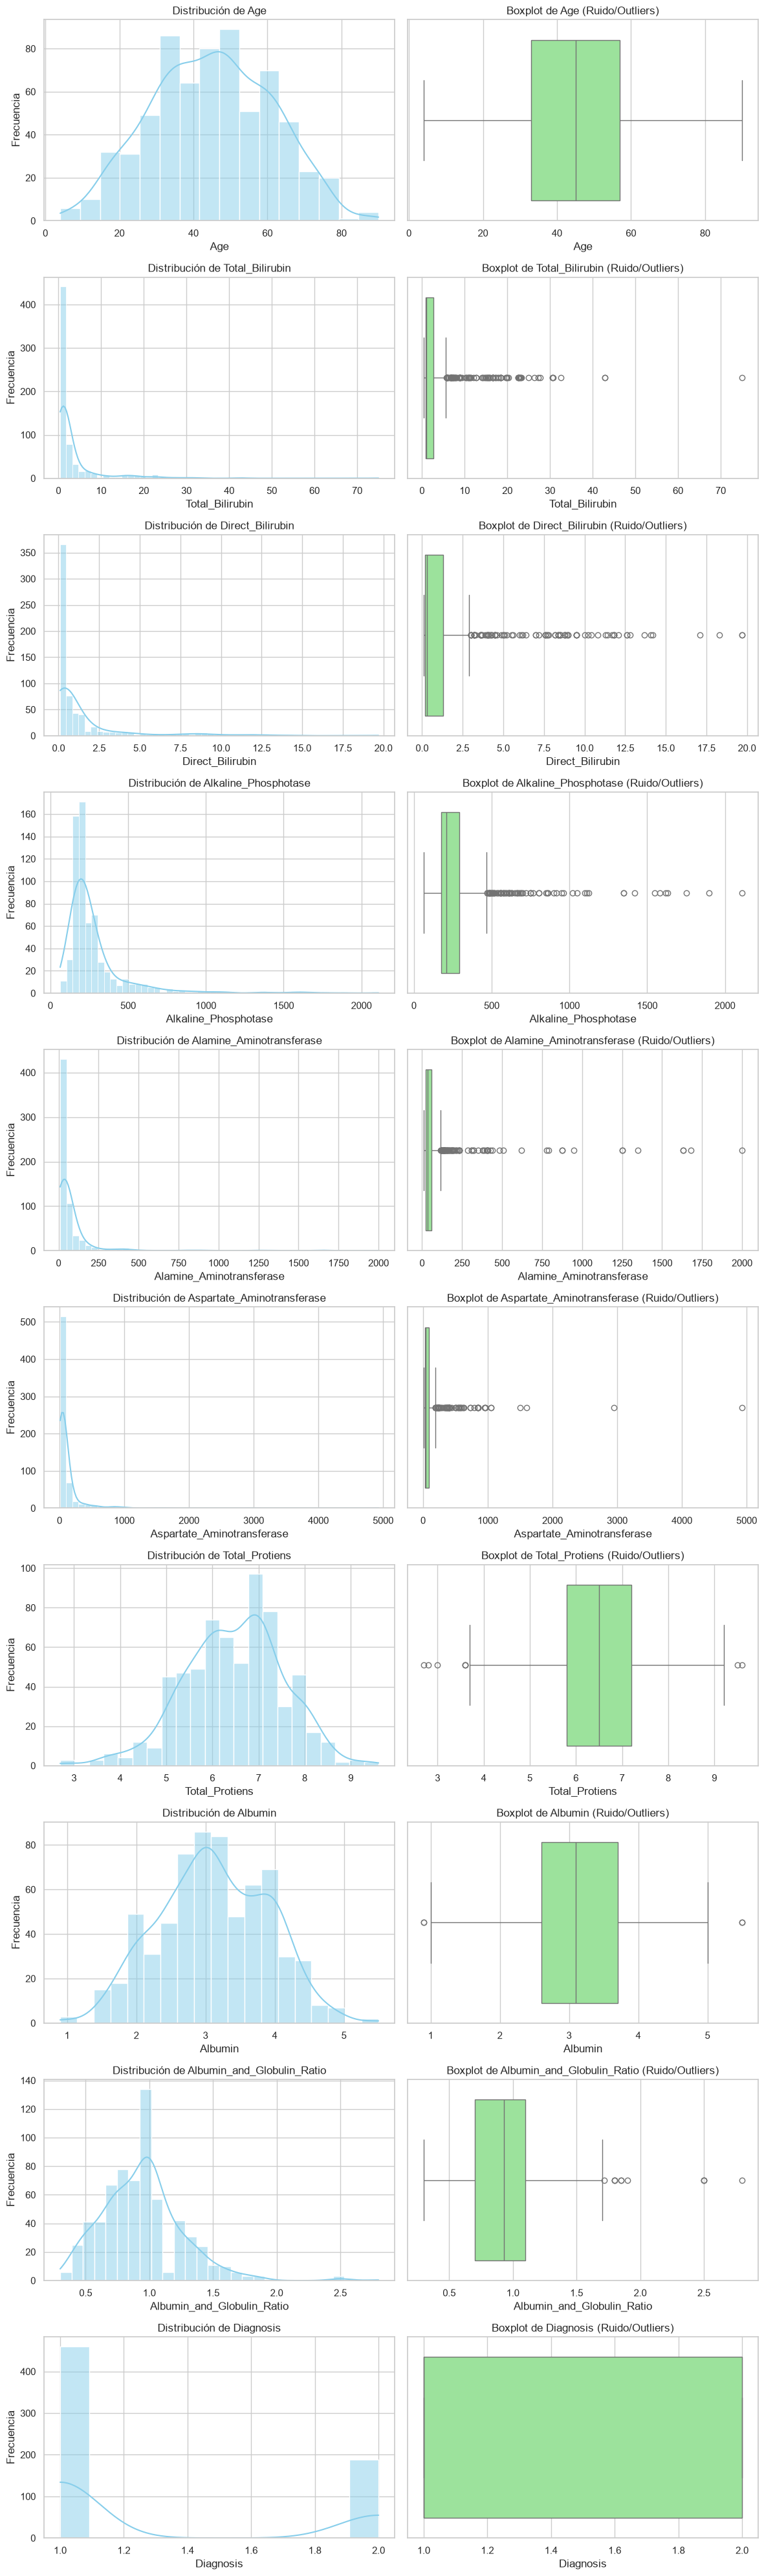

In [5]:
# 3. Análisis Univariable - Variables Numéricas
print("=" * 50)
print("ANÁLISIS UNIVARIABLE - DESCRIPCIÓN ESTADÍSTICA")
print("=" * 50)

# Seleccionamos solo las variables numéricas
num_cols = df.select_dtypes(include=["float64", "Int64"]).columns
display(df[num_cols].describe())

# 4. Visualización de Distribución y Detección de Ruido (Outliers)
logging.info("Generando gráficos de distribución y diagramas de caja...")

# Configuramos un grid de gráficos (N filas x 2 columnas)
fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, figsize=(12, 4 * len(num_cols)))

for i, col in enumerate(num_cols):
    # Histograma (Distribución y Sesgo)
    sns.histplot(data=df, x=col, kde=True, ax=axes[i, 0], color="skyblue")
    axes[i, 0].set_title(f"Distribución de {col}")
    axes[i, 0].set_ylabel("Frecuencia")

    # Boxplot (Valores Atípicos / Ruido)
    sns.boxplot(data=df, x=col, ax=axes[i, 1], color="lightgreen")
    axes[i, 1].set_title(f"Boxplot de {col} (Ruido/Outliers)")

plt.tight_layout()
plt.show()

### 📝 Conclusiones del Análisis Univariable e Identificación de Tareas (Feature Engineering)

**1. Duplicados y Nulos:**
* **Hallazgo:** Se detectaron 60 filas exactamente duplicadas (aprox. 9% del dataset). Adicionalmente, existen nulos en `Diagnosis` (15) y en otras variables médicas.
* **Acción futura (Feature Engineering):** Eliminar duplicados para evitar *Data Leakage*. Eliminar filas sin variable objetivo y aplicar técnicas de imputación (ej. Mediana) para las predictoras numéricas.

**2. Tipos de Distribución y Ruido (Variables Numéricas):**
* **Distribuciones casi Normales (Gausianas):** Las variables `Age`, `Total_Protiens` y `Albumin` presentan una distribución en forma de campana (simétrica) y sus *boxplots* muestran una ausencia casi total de valores atípicos. No requerirán transformaciones complejas.
* **Distribuciones con Asimetría Positiva Extrema (Sesgo a la derecha):** Las variables enzimáticas e indicadoras de función hepática (`Total_Bilirubin`, `Direct_Bilirubin`, `Alkaline_Phosphotase`, `Alamine_Aminotransferase`, `Aspartate_Aminotransferase`) presentan la mayoría de sus valores concentrados cerca de cero, con una larga cola extendiéndose hacia la derecha. 
* **Interpretación Clínica del Ruido:** Los *boxplots* de este segundo grupo muestran cientos de puntos alejados (outliers). Clínicamente, estos no son errores o ruido estocástico; son mediciones reales que indican daño hepático severo.
* **Acción futura:** Conservar los *outliers*. Aplicar transformaciones matemáticas (como *Log Transform* o escalado robusto) para mitigar el sesgo y ayudar a que los modelos converjan mejor sin perder la señal predictiva de los valores extremos.

**3. Desbalance de la Variable Objetivo (Target):**
* **Hallazgo:** El último histograma (`Diagnosis`) muestra una clara diferencia en las proporciones de las clases. Hay una cantidad significativamente mayor de pacientes con enfermedad hepática (clase 1) en comparación con pacientes sanos (clase 2).
* **Acción futura:** El dataset está desbalanceado. Durante el entrenamiento del modelo, será necesario implementar estrategias como la asignación de pesos a las clases (`class_weight='balanced'`) o técnicas de sobremuestreo (SMOTE) para evitar que el algoritmo se sesgue hacia la clase mayoritaria.

## Analisis bivariable

2026-08-20 23:06:19,210 - INFO - Iniciando análisis bivariable...


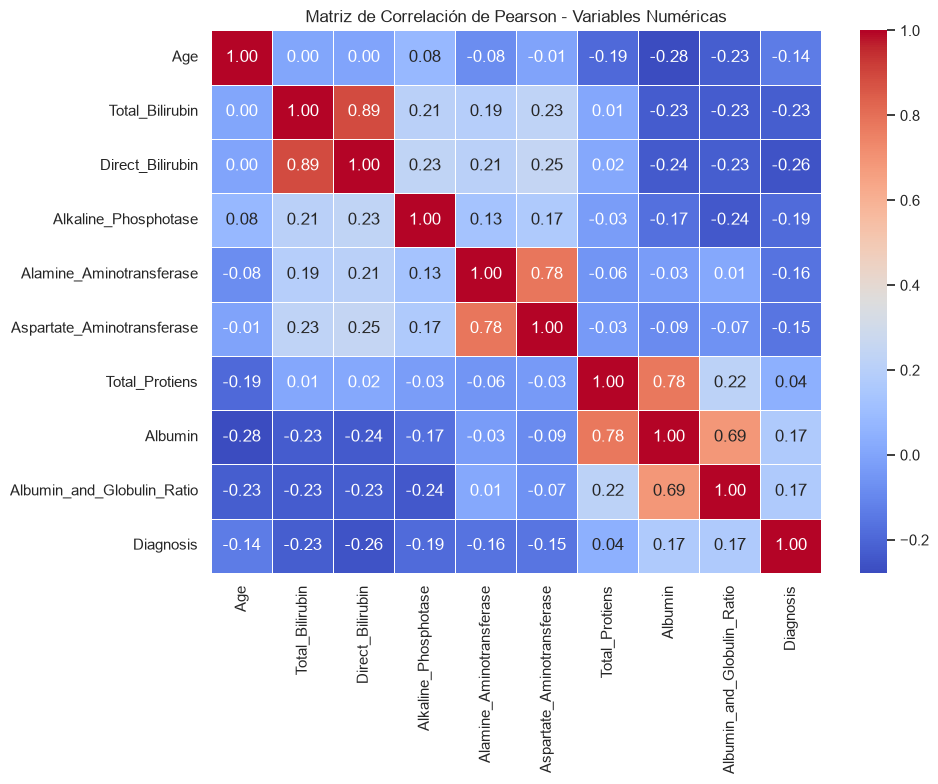

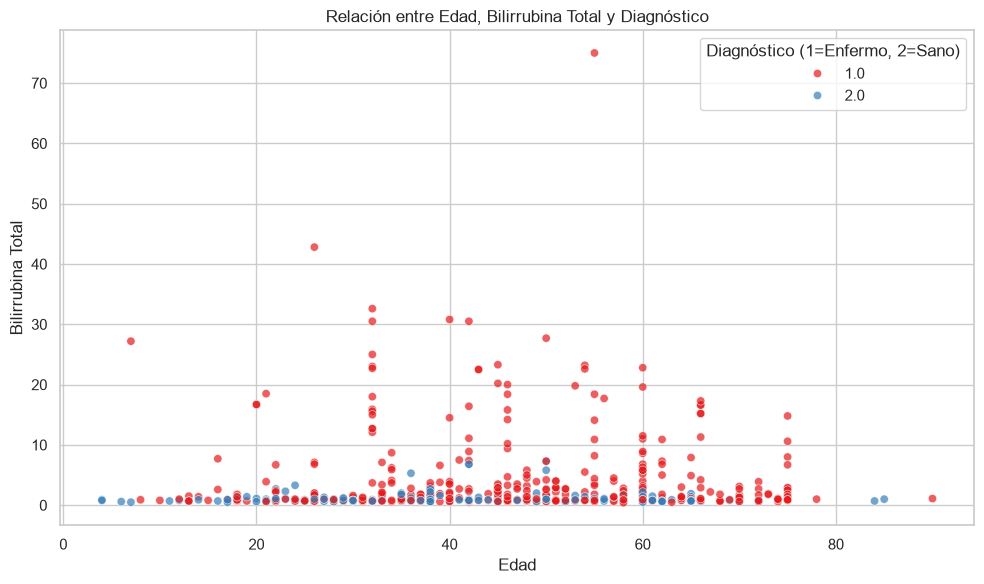

In [6]:
# ==========================================
# 6. ANÁLISIS BIVARIABLE
# ==========================================
logging.info("Iniciando análisis bivariable...")

# Se conservan duplicados y valores atípicos para no ocultar hallazgos del dataset
df_bivariable = df.copy()

# 6.1 Matriz de Correlación (Linealidad entre variables numéricas)
plt.figure(figsize=(10, 8))
corr_matrix = df_bivariable.select_dtypes(include=["float64", "Int64"]).corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación de Pearson - Variables Numéricas")
plt.tight_layout()
plt.show()

# 6.2 Relación clave: Bilirrubina Total vs Edad agrupado por Diagnóstico
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_bivariable, x="Age", y="Total_Bilirubin", hue="Diagnosis", palette="Set1", alpha=0.7
)
plt.title("Relación entre Edad, Bilirrubina Total y Diagnóstico")
plt.xlabel("Edad")
plt.ylabel("Bilirrubina Total")
plt.legend(title="Diagnóstico (1=Enfermo, 2=Sano)")
plt.tight_layout()
plt.show()

### 6.3 Relación entre variables categóricas y el diagnóstico

Se analiza `Gender` frente a `Diagnosis`. Las filas sin diagnóstico se excluyen únicamente de esta comparación porque no tienen una clase objetivo conocida.

In [ ]:
# Para relaciones con el target se excluyen solo las filas sin diagnóstico
df_target = df.dropna(subset=["Diagnosis"]).copy()
df_target["Diagnosis_code"] = df_target["Diagnosis"].astype("int64")

gender_diagnosis = (
    pd.crosstab(
        df_target["Gender"],
        df_target["Diagnosis_code"],
        normalize="index",
    )
    .mul(100)
    .round(2)
)
gender_diagnosis.columns.name = "Diagnosis (%)"

print("Distribución porcentual del diagnóstico dentro de cada género:")
display(gender_diagnosis)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(
    data=df_target,
    x="Gender",
    hue="Diagnosis_code",
    palette="Set1",
    ax=axes[0],
)
axes[0].set_title("Conteo de pacientes por género y diagnóstico")
axes[0].set_xlabel("Género")
axes[0].set_ylabel("Número de pacientes")
axes[0].legend(title="Diagnóstico")

gender_diagnosis.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set1")
axes[1].set_title("Proporción del diagnóstico dentro de cada género")
axes[1].set_xlabel("Género")
axes[1].set_ylabel("Porcentaje (%)")
axes[1].legend(title="Diagnóstico")
plt.tight_layout()
plt.show()

### 6.4 Variables numéricas condicionadas por el diagnóstico

Las siguientes tablas y diagramas comparan las mediciones clínicas entre las dos clases. Se muestran los outliers porque pueden representar señales patológicas y no deben eliminarse durante el EDA.

In [ ]:
feature_numeric_cols = [
    column for column in df.select_dtypes(include="number").columns if column != "Diagnosis"
]

summary_by_diagnosis = (
    df_target.groupby("Diagnosis_code", observed=True)[feature_numeric_cols]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)
print("Resumen estadístico de las variables numéricas por diagnóstico:")
display(summary_by_diagnosis.T)

fig, axes = plt.subplots(3, 3, figsize=(15, 14))
axes = axes.ravel()

for axis, column in zip(axes, feature_numeric_cols, strict=True):
    sns.boxplot(
        data=df_target,
        x="Diagnosis_code",
        hue="Diagnosis_code",
        y=column,
        showfliers=True,
        palette="Set2",
        legend=False,
        ax=axis,
    )
    axis.set_title(f"{column} por diagnóstico")
    axis.set_xlabel("Diagnóstico (1=enfermedad, 2=sin enfermedad)")
    axis.set_ylabel(column)

for axis in axes[len(feature_numeric_cols) :]:
    axis.remove()

plt.tight_layout()
plt.show()

### 6.5 Asociaciones numéricas y relaciones clínicas

La correlación con `Diagnosis_code` es una medida exploratoria equivalente a una correlación punto-biserial. No implica causalidad y debe confirmarse posteriormente con validación estadística y modelos entrenados sin fuga de información.

In [ ]:
association_df = df_target[feature_numeric_cols].copy()
association_df["Diagnosis_code"] = df_target["Diagnosis_code"]

target_correlations = (
    association_df.corr(numeric_only=True)["Diagnosis_code"].drop("Diagnosis_code").sort_values()
)
target_correlations = target_correlations.rename("Pearson_vs_Diagnosis").to_frame()
display(target_correlations.round(3))

clinical_pairs = [
    ("Total_Bilirubin", "Direct_Bilirubin"),
    ("Alamine_Aminotransferase", "Aspartate_Aminotransferase"),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, (x_column, y_column) in zip(axes, clinical_pairs, strict=True):
    sns.scatterplot(
        data=df_target,
        x=x_column,
        y=y_column,
        hue="Diagnosis_code",
        palette="Set1",
        alpha=0.7,
        ax=axis,
    )
    axis.set_title(f"{x_column} frente a {y_column}")
    axis.set_xlabel(x_column)
    axis.set_ylabel(y_column)

plt.tight_layout()
plt.show()

## 7. Análisis multivariable

El análisis multivariable combina más de dos atributos para observar patrones conjuntos. Se mantendrán los valores atípicos y se excluirán valores nulos únicamente cuando una visualización necesite las variables involucradas.

In [ ]:
df_multi = df.dropna(subset=["Diagnosis"]).copy()
df_multi["Diagnosis_code"] = df_multi["Diagnosis"].astype("int64")

age_bins = [0, 20, 40, 60, 80, 100]
age_labels = ["0-20", "21-40", "41-60", "61-80", "81-100"]
df_multi["Age_group"] = pd.cut(
    df_multi["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True,
)
df_multi["Is_liver_disease"] = df_multi["Diagnosis_code"].eq(1)

age_gender_summary = (
    df_multi.groupby(["Age_group", "Gender"], observed=True)["Is_liver_disease"]
    .agg(["count", "mean"])
    .rename(columns={"count": "Patients", "mean": "Disease_rate"})
)
age_gender_summary["Disease_rate"] = age_gender_summary["Disease_rate"].mul(100).round(2)
print("Tasa de enfermedad por grupo de edad y género:")
display(age_gender_summary)

disease_rate_heatmap = age_gender_summary["Disease_rate"].unstack()
plt.figure(figsize=(10, 6))
sns.heatmap(
    disease_rate_heatmap,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    cbar_kws={"label": "Enfermedad hepática (%)"},
)
plt.title("Tasa de enfermedad combinando edad y género")
plt.xlabel("Género")
plt.ylabel("Grupo de edad")
plt.tight_layout()
plt.show()

### 7.1 Patrones conjuntos entre pruebas clínicas

Este gráfico combina bilirrubinas, diagnóstico, género y edad. Permite observar si la separación visual entre clases se mantiene cuando se incorporan simultáneamente características demográficas y clínicas.

In [ ]:
clinical_plot_data = df_multi.dropna(
    subset=["Total_Bilirubin", "Direct_Bilirubin", "Gender", "Age"]
).copy()
clinical_plot_data["Age"] = clinical_plot_data["Age"].astype("float64")

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=clinical_plot_data,
    x="Total_Bilirubin",
    y="Direct_Bilirubin",
    hue="Diagnosis_code",
    style="Gender",
    size="Age",
    sizes=(25, 180),
    palette="Set1",
    alpha=0.7,
)
plt.title("Relación conjunta entre bilirrubinas, diagnóstico, género y edad")
plt.xlabel("Bilirrubina total")
plt.ylabel("Bilirrubina directa")
plt.tight_layout()
plt.show()

### 7.2 Vista conjunta de las principales variables

El siguiente `pairplot` resume relaciones y distribuciones de un subconjunto clínicamente relevante. Se limita el número de variables para conservar una visualización interpretable.

In [ ]:
pairplot_columns = [
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Albumin",
    "Diagnosis_code",
]
pairplot_data = df_multi[pairplot_columns].dropna()

pair_grid = sns.pairplot(
    pairplot_data,
    hue="Diagnosis_code",
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.5, "s": 30},
)
pair_grid.fig.suptitle("Relaciones multivariables de variables clínicas seleccionadas")
pair_grid.fig.subplots_adjust(top=0.95)
plt.show()

## Conclusiones generales del EDA

### Hallazgos principales

- El dataset contiene 663 registros y 11 atributos. `Diagnosis` es el target supervisado; sus clases son 1 (enfermedad hepática) y 2 (sin enfermedad).
- El target tiene valores faltantes y las variables clínicas también presentan datos nulos. Las filas sin target se deben excluir de entrenamiento y evaluación, mientras que los predictores requieren una estrategia de imputación.
- Se observaron 60 filas exactamente duplicadas. Esta situación debe investigarse con el origen de los datos antes de decidir si son registros repetidos o pacientes distintos con mediciones iguales.
- La clase de enfermedad es mayoritaria. La distribución no debe balancearse durante el EDA; el tratamiento corresponde a la etapa de entrenamiento.
- Las variables con mayor utilidad potencial son las pruebas hepáticas, especialmente bilirrubinas, transaminasas, fosfatasa alcalina, albúmina y su razón albúmina/globulina. `Age` y `Gender` pueden aportar contexto demográfico. Ninguna variable aislada debe interpretarse como diagnóstico suficiente.
- Las diferencias observadas entre grupos y los patrones conjuntos son asociaciones descriptivas. No demuestran causalidad ni permiten establecer umbrales clínicos por sí solas.

### Decisiones para la siguiente etapa

- **Limpieza y validación:** verificar rangos no negativos de las pruebas, edad válida, categorías permitidas de `Gender` y valores de target limitados a 1 y 2. Las reglas de rango clínico deben confirmarse con unidades y referencias médicas.
- **Duplicados:** definir una política documentada y aplicarla antes de separar los datos, evitando eliminar observaciones automáticamente.
- **Valores nulos:** imputar dentro de un pipeline ajustado exclusivamente con el conjunto de entrenamiento; no usar estadísticas calculadas con todo el dataset.
- **Transformaciones:** evaluar `log1p` o transformaciones robustas para variables con sesgo positivo y escalado robusto para reducir la influencia numérica de los valores extremos sin eliminarlos.
- **Codificación:** convertir `Gender` a una representación numérica dentro del pipeline y convertir el target a una codificación binaria coherente antes del modelado.
- **Evaluación:** realizar una partición estratificada y priorizar Recall de la clase enferma, complementándolo con F1-score, ROC-AUC y la matriz de confusión.

### Heurística inicial y datos adicionales

- Una heurística viable como línea base sería marcar riesgo cuando exista una combinación de bilirrubinas o transaminasas elevadas y alteraciones de albúmina. No se fijan umbrales en este notebook porque deben proceder de referencias clínicas o aprenderse únicamente con el conjunto de entrenamiento.
- Esta heurística serviría como comparación transparente, no como diagnóstico médico ni como sustituto de un modelo validado.
- Serían útiles las unidades de medida, rangos de referencia por laboratorio, fecha y lugar de la medición, método utilizado para establecer el diagnóstico, antecedentes clínicos, consumo de alcohol o medicamentos y mediciones repetidas por paciente.

Con esto finaliza el análisis exploratorio. El siguiente issue puede implementar la limpieza y el feature engineering sin mezclar esas transformaciones con los hallazgos descriptivos de este notebook.